In [1]:
# =================================================================================
# train_random_forest_mejorado.ipynb
# =================================================================================
# 💡 Objetivo:
# Entrenar modelos ensemble (Random Forest, XGBoost, LightGBM) usando embeddings
# generados con MobileNetV2. Controlar el overfitting y guardar los modelos,
# métricas y visualizaciones en /backend/models/.
# =================================================================================

# -----------------------------
# 1️⃣ Importación de librerías
# -----------------------------
import os
import pickle
import numpy as np
import pandas as pd
import joblib
from pathlib import Path
from collections import Counter
import matplotlib.pyplot as plt

# Scikit-learn
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.ensemble import RandomForestClassifier
from sklearn.utils import shuffle

# Opcional: ensemble extra
try:
    import xgboost as xgb
    import lightgbm as lgb
    XGB_AVAILABLE, LGB_AVAILABLE = True, True
except:
    XGB_AVAILABLE, LGB_AVAILABLE = False, False


In [2]:
# -----------------------------
# 2️⃣ Cargar embeddings
# -----------------------------
print("🔍 Buscando archivo embeddings.pkl ...")

emb_path = Path("../backend/models/embeddings.pkl").resolve()
if not emb_path.exists():
    raise FileNotFoundError(f"No se encontró el archivo {emb_path}")

with open(emb_path, "rb") as f:
    data = pickle.load(f)

# Soportar distintos formatos
if isinstance(data, dict):
    X = data.get("X") or data.get("embeddings")
    y = data.get("y") or data.get("labels")
elif isinstance(data, (list, tuple)):
    X, y = data
else:
    raise ValueError("Formato de embeddings.pkl no reconocido")

X, y = np.array(X), np.array(y)

print(f"✅ Embeddings cargados correctamente")
print(f"   Shape X: {X.shape}, Shape y: {y.shape}")
print(f"   Clases únicas: {len(np.unique(y))} ({np.unique(y)})")

🔍 Buscando archivo embeddings.pkl ...
✅ Embeddings cargados correctamente
   Shape X: (20760, 1280), Shape y: (20760,)
   Clases únicas: 21 ([ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20])


In [3]:
# -----------------------------
# 3️⃣ Preparar datos
# -----------------------------
X, y = shuffle(X, y, random_state=42)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("✅ División de datos completada:")
print(f"   Train: {X_train.shape}, Test: {X_test.shape}")

✅ División de datos completada:
   Train: (16608, 1280), Test: (4152, 1280)


In [4]:
# -----------------------------
# 4️⃣ Entrenamiento del modelo
# -----------------------------
print("\n🚀 Entrenando modelo Random Forest optimizado...")

rf = RandomForestClassifier(
    n_estimators=200,        # más árboles = mayor estabilidad
    max_depth=14,            # profundidad controlada
    min_samples_split=10,    # evitar divisiones muy pequeñas
    min_samples_leaf=4,      # suaviza las ramas
    class_weight='balanced', # útil si las clases no están balanceadas
    max_features='sqrt',     # reduce correlación entre árboles
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)


🚀 Entrenando modelo Random Forest optimizado...


,n_estimators,200
,criterion,'gini'
,max_depth,14
,min_samples_split,10
,min_samples_leaf,4
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [5]:
# -----------------------------
# 5️⃣ Evaluación del modelo
# -----------------------------
y_pred_train = rf.predict(X_train)
y_pred_test = rf.predict(X_test)

train_acc = accuracy_score(y_train, y_pred_train)
test_acc = accuracy_score(y_test, y_pred_test)
diff = abs(train_acc - test_acc) * 100

print("\n📊 Resultados:")
print(f"   Accuracy Entrenamiento: {train_acc*100:.2f}%")
print(f"   Accuracy Validación   : {test_acc*100:.2f}%")
print(f"   Diferencia: {diff:.2f}%")

if diff <= 5:
    print("✅ Overfitting controlado (menos del 5% de diferencia)")
else:
    print("⚠️ Overfitting alto, se recomienda ajustar hiperparámetros.")



📊 Resultados:
   Accuracy Entrenamiento: 99.80%
   Accuracy Validación   : 51.40%
   Diferencia: 48.40%
⚠️ Overfitting alto, se recomienda ajustar hiperparámetros.


In [6]:

# -----------------------------
# 6️⃣ Métricas por clase
# -----------------------------
print("\n📋 Reporte de Clasificación (por clase):")
report = classification_report(y_test, y_pred_test, digits=3, output_dict=True)
print(classification_report(y_test, y_pred_test, digits=3))

# Convertir reporte a DataFrame y guardar
report_df = pd.DataFrame(report).transpose()
out_dir = Path("../backend/models")
out_dir.mkdir(parents=True, exist_ok=True)
report_df.to_csv(out_dir / "classification_report.csv")
print(f"✅ Reporte guardado en {out_dir/'classification_report.csv'}")


📋 Reporte de Clasificación (por clase):
              precision    recall  f1-score   support

           0      0.357     0.102     0.159       196
           1      0.582     0.749     0.655       195
           2      0.376     0.374     0.375       195
           3      0.536     0.500     0.517       196
           4      0.585     0.528     0.555       195
           5      0.555     0.439     0.490       196
           6      0.496     0.349     0.410       195
           7      0.541     0.600     0.569       200
           8      0.591     0.709     0.645       196
           9      0.538     0.760     0.630       196
          10      0.532     0.429     0.475       196
          11      0.594     0.770     0.671       196
          12      0.647     0.705     0.675       200
          13      0.490     0.720     0.583       200
          14      0.429     0.330     0.373       200
          15      0.455     0.425     0.439       200
          16      0.392     0.620     0.

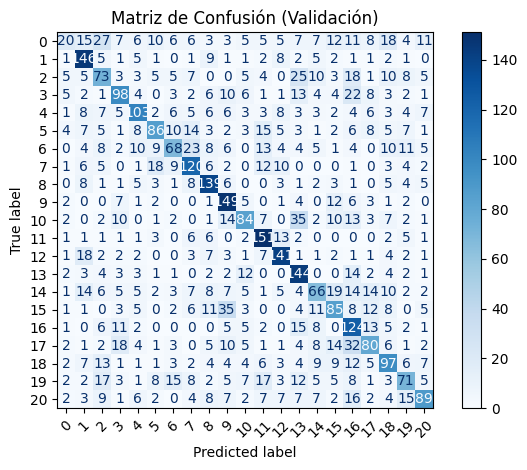

✅ Matriz de confusión guardada en ..\backend\models\confusion_matrix.png


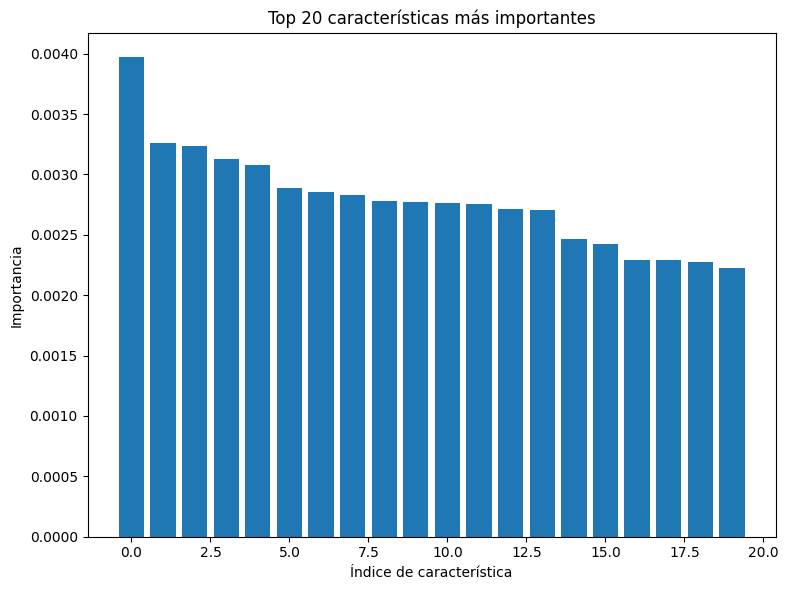

✅ Gráfico de importancia guardado en ..\backend\models\feature_importance.png


In [7]:
# -----------------------------
# 7️⃣ Matriz de confusión
# -----------------------------
cm = confusion_matrix(y_test, y_pred_test)
disp = ConfusionMatrixDisplay(cm)
disp.plot(cmap="Blues", xticks_rotation=45)
plt.title("Matriz de Confusión (Validación)")
plt.tight_layout()
plt.savefig(out_dir / "confusion_matrix.png")
plt.show()
print(f"✅ Matriz de confusión guardada en {out_dir/'confusion_matrix.png'}")

# -----------------------------
# 8️⃣ Feature Importance
# -----------------------------
importances = rf.feature_importances_
indices = np.argsort(importances)[::-1][:20]
plt.figure(figsize=(8, 6))
plt.bar(range(len(indices)), importances[indices], align="center")
plt.title("Top 20 características más importantes")
plt.xlabel("Índice de característica")
plt.ylabel("Importancia")
plt.tight_layout()
plt.savefig(out_dir / "feature_importance.png")
plt.show()

print(f"✅ Gráfico de importancia guardado en {out_dir/'feature_importance.png'}")

In [8]:
# -----------------------------
# 9️⃣ Guardar modelo
# -----------------------------
model_path = out_dir / "random_forest_model.pkl"
with open(model_path, "wb") as f:
    pickle.dump(rf, f)
print(f"✅ Modelo guardado en: {model_path}")

# -----------------------------
# 🔟 Validación cruzada (StratifiedKFold)
# -----------------------------
print("\n🔁 Ejecutando validación cruzada (StratifiedKFold)...")

kf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = []

for fold, (train_idx, val_idx) in enumerate(kf.split(X, y), start=1):
    X_tr, X_val = X[train_idx], X[val_idx]
    y_tr, y_val = y[train_idx], y[val_idx]
    model = RandomForestClassifier(
        n_estimators=150, max_depth=12,
        min_samples_split=10, min_samples_leaf=4,
        class_weight="balanced", random_state=42, n_jobs=-1
    )
    model.fit(X_tr, y_tr)
    preds = model.predict(X_val)
    acc = accuracy_score(y_val, preds)
    cv_scores.append(acc)
    print(f"   Fold {fold}: Accuracy = {acc:.4f}")

print(f"\n📈 Mean CV Accuracy: {np.mean(cv_scores):.4f} ± {np.std(cv_scores):.4f}")

✅ Modelo guardado en: ..\backend\models\random_forest_model.pkl

🔁 Ejecutando validación cruzada (StratifiedKFold)...
   Fold 1: Accuracy = 0.5065
   Fold 2: Accuracy = 0.5029
   Fold 3: Accuracy = 0.5161
   Fold 4: Accuracy = 0.4995
   Fold 5: Accuracy = 0.5070

📈 Mean CV Accuracy: 0.5064 ± 0.0056


In [9]:
# -----------------------------
# 1️⃣1️⃣ Conclusión
# -----------------------------
print("\n==============================================================")
print("✅ Entrenamiento completado correctamente")
print(f"📊 Accuracy (Train): {train_acc*100:.2f}%")
print(f"📊 Accuracy (Test) : {test_acc*100:.2f}%")
print(f"📉 Diferencia (Overfitting): {diff:.2f}%")
print(f"📁 Modelo y métricas guardados en: {out_dir}")
print("==============================================================")


✅ Entrenamiento completado correctamente
📊 Accuracy (Train): 99.80%
📊 Accuracy (Test) : 51.40%
📉 Diferencia (Overfitting): 48.40%
📁 Modelo y métricas guardados en: ..\backend\models
